# 03 — Evaluation, Ablations & Visualization

This is the eval. I run all four detectors over the labeled test set in parallel (bounded by `MAX_CONCURRENCY`), gather precision / recall / F1 / accuracy + confusion matrix per method, and save the charts and raw numbers.

The detectors and the LLM-judge code below are pasted from `02_interactive.ipynb` — same prompt, same Pydantic schema, same `error` propagation. The notebook needs to run standalone (assignment requires Restart-and-Run-All), and centralizing into a config module is overkill at this scale, so I duplicate.

Outputs in `results/`:
- `comparison_chart.png` — main bar chart (4 methods × 4 metrics)
- `threshold_ablation.png` — embedding-threshold sweep (cheap, no LLM)
- `k_ablation.png` — RAG / hybrid `k` sweep
- `alpha_ablation.png` — hybrid α sweep
- `metrics.json`, `predictions.json` — raw numbers


In [1]:
%pip -q install faiss-cpu google-genai python-dotenv rank_bm25 numpy matplotlib pandas scikit-learn pydantic

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import asyncio
from pathlib import Path

from dotenv import load_dotenv

ROOT = Path.cwd()
DATA_DIR = ROOT / 'data'
CORPUS_DIR = DATA_DIR / 'reference_corpus'
TEST_DATASET_DIR = DATA_DIR / 'test_dataset'
INDEX_DIR = ROOT / 'indexes'
RESULTS_DIR = ROOT / 'results'

load_dotenv()
GEMINI_API_KEY = os.getenv('GEMINI_API_KEY')
assert GEMINI_API_KEY, 'GEMINI_API_KEY is required (set it in .env)'

# keep in sync with 01_indexing.ipynb / 02_interactive.ipynb
EMBED_MODEL = 'gemini-embedding-001'
LLM_MODEL = 'gemini-2.5-flash'
EMBED_BATCH_SIZE = 50     # texts per embed_content call
DEFAULT_K = 5             # retrieved candidates passed to the LLM judge
DEFAULT_ALPHA = 0.5       # hybrid RAG fusion weight (1.0 = dense only)
DEFAULT_CANDIDATE_POOL = 20  # depth of dense + sparse lists before fusion
DEFAULT_EMBED_THRESHOLD = 0.82  # cosine threshold for the embedding-only detector
RETRY_ATTEMPTS = 6
RETRY_BASE_SECONDS = 2

# 03 fires ~400 LLM calls; 02 only does a handful so it stays at 6.
# 20 concurrent × ~5s/call ≈ 240 RPM — well under tier-1 Flash's 1000 RPM cap.
MAX_CONCURRENCY = 20

RESULTS_DIR.mkdir(exist_ok=True)

In [3]:
import re
import json
import numpy as np
import faiss

_TOKEN_RE = re.compile(r'[A-Za-z_][A-Za-z0-9_]*|[0-9]+')
_CAMEL_RE = re.compile(r'(?<=[a-z])(?=[A-Z])|(?<=[A-Z])(?=[A-Z][a-z])')


def tokenize_code(text: str) -> list[str]:
    """Split code into lowercase subtokens — splits camelCase and snake_case."""
    out: list[str] = []
    for raw in _TOKEN_RE.findall(text):
        for piece in _CAMEL_RE.split(raw):
            for sub in piece.split('_'):
                if sub:
                    out.append(sub.lower())
    return out


def dense_search(faiss_index, qvec: np.ndarray, k: int) -> list[tuple[int, float]]:
    scores, ids = faiss_index.search(qvec, k=k)
    return [(int(i), float(s)) for s, i in zip(scores[0], ids[0]) if i >= 0]


def bm25_search(bm25, query: str, k: int) -> list[tuple[int, float]]:
    scores = bm25.get_scores(tokenize_code(query))
    if k >= len(scores):
        order = np.argsort(-scores)
    else:
        order = np.argpartition(-scores, k)[:k]
        order = order[np.argsort(-scores[order])]
    return [(int(i), float(scores[i])) for i in order]


def reciprocal_rank_fusion(
    dense: list[tuple[int, float]],
    sparse: list[tuple[int, float]],
    alpha: float = 0.5,
    k_rrf: int = 60,
) -> list[tuple[int, float]]:
    """Weighted RRF — alpha=1.0 is dense-only, alpha=0.0 is sparse-only."""
    fused: dict[int, float] = {}
    for rank, (idx, _) in enumerate(dense):
        fused[idx] = fused.get(idx, 0.0) + alpha / (k_rrf + rank + 1)
    for rank, (idx, _) in enumerate(sparse):
        fused[idx] = fused.get(idx, 0.0) + (1 - alpha) / (k_rrf + rank + 1)
    return sorted(fused.items(), key=lambda kv: -kv[1])


In [4]:
import pickle

# FAISS already holds the embedding vectors — no need to load embeddings.npy here.
faiss_index = faiss.read_index(str(INDEX_DIR / 'faiss.index'))
with open(INDEX_DIR / 'chunks.pkl', 'rb') as f:
    chunks: list[str] = pickle.load(f)
with open(INDEX_DIR / 'metas.pkl', 'rb') as f:
    metas: list[dict] = pickle.load(f)
with open(INDEX_DIR / 'bm25.pkl', 'rb') as f:
    bm25 = pickle.load(f)['bm25']

print(f'Loaded {len(chunks)} chunks; FAISS ntotal={faiss_index.ntotal}')

Loaded 70 chunks; FAISS ntotal=70


In [5]:
from google import genai
from google.genai import types

client = genai.Client(api_key=GEMINI_API_KEY)
_gemini_sem = asyncio.Semaphore(MAX_CONCURRENCY)


async def _gemini_call(call_fn):
    """Bounded-concurrency Gemini call with exponential backoff.

    Sleep happens *outside* the semaphore so a retrying coroutine doesn't
    hold its slot and stall the others.
    """
    last_err: Exception | None = None
    for attempt in range(RETRY_ATTEMPTS):
        try:
            async with _gemini_sem:
                return await call_fn()
        except Exception as exc:
            last_err = exc
            await asyncio.sleep(RETRY_BASE_SECONDS ** attempt)
    raise RuntimeError(f'Gemini call failed after {RETRY_ATTEMPTS} attempts: {last_err}')


async def _embed_batch(texts: list[str], task_type: str) -> list[list[float]]:
    resp = await _gemini_call(lambda: client.aio.models.embed_content(
        model=EMBED_MODEL,
        contents=texts,
        config=types.EmbedContentConfig(task_type=task_type),
    ))
    return [e.values for e in resp.embeddings]


async def embed_query(text: str) -> np.ndarray:
    [vec] = await _embed_batch([text], 'RETRIEVAL_QUERY')
    out = np.asarray([vec], dtype='float32')
    faiss.normalize_L2(out)
    return out

In [6]:
from pydantic import BaseModel


class JudgeVerdict(BaseModel):
    is_plagiarism: bool
    confidence: float
    reason: str


JUDGE_PROMPT = (
    'You are a code-plagiarism analyst. The CANDIDATE snippet is suspected of being '
    'copied from one of the REFERENCE snippets, possibly with cosmetic changes '
    '(renames, comment removal, minor refactors). Decide whether the CANDIDATE is a '
    'semantic clone of any REFERENCE — i.e. it implements the same algorithm with the '
    'same control-flow shape — versus an independent implementation of a similar problem '
    'or unrelated code. An independent implementation of the same problem is NOT plagiarism, '
    'even if the algorithms are mathematically related (e.g. Dijkstra vs A*).'
)


async def llm_judge(candidate: str, references: list[str]) -> dict:
    """Ask the LLM to decide plagiarism. Errors come back via 'error' (empty when OK)."""
    refs_block = '\n\n'.join(
        f'### REFERENCE {i + 1}\n```python\n{ref}\n```' for i, ref in enumerate(references)
    )
    prompt = (
        f'{JUDGE_PROMPT}\n\n'
        f'### CANDIDATE\n```python\n{candidate}\n```\n\n'
        f'{refs_block}'
    )
    try:
        resp = await _gemini_call(lambda: client.aio.models.generate_content(
            model=LLM_MODEL,
            contents=prompt,
            config=types.GenerateContentConfig(
                temperature=0.0,
                response_mime_type='application/json',
                response_schema=JudgeVerdict,
            ),
        ))
    except Exception as exc:
        return {
            'is_plagiarism': False, 'confidence': 0.0, 'reason': '',
            'error': f'llm: {exc}',
        }
    verdict: JudgeVerdict | None = resp.parsed
    if verdict is None:
        return {
            'is_plagiarism': False, 'confidence': 0.0, 'reason': '',
            'error': 'no parsed verdict',
        }
    return {
        'is_plagiarism': bool(verdict.is_plagiarism),
        'confidence': float(verdict.confidence),
        'reason': verdict.reason[:300],
        'error': '',
    }

In [7]:
async def detect_embedding(
    snippet: str,
    *,
    k: int = DEFAULT_K,
    threshold: float = DEFAULT_EMBED_THRESHOLD,
) -> dict:
    qvec = await embed_query(snippet)
    hits = dense_search(faiss_index, qvec, k=k)
    top_score = hits[0][1] if hits else 0.0
    return {
        'method': 'embedding',
        'is_plagiarism': bool(top_score >= threshold),
        'score': float(top_score),
        'threshold': threshold,
        'top_matches': [{'similarity': s, **metas[i]} for i, s in hits],
    }


async def detect_llm(snippet: str) -> dict:
    """Send the whole reference corpus to the LLM in one prompt — no sharding."""
    judged = await llm_judge(snippet, chunks)
    return {
        'method': 'llm_full',
        'is_plagiarism': judged['is_plagiarism'],
        'score': judged['confidence'],
        'reason': judged['reason'],
        'error': judged.get('error', ''),
        'context_chunks': len(chunks),
    }


async def detect_rag(snippet: str, *, k: int = DEFAULT_K) -> dict:
    qvec = await embed_query(snippet)
    hits = dense_search(faiss_index, qvec, k=k)
    refs = [chunks[i] for i, _ in hits]
    judged = await llm_judge(snippet, refs)
    return {
        'method': 'rag',
        'is_plagiarism': judged['is_plagiarism'],
        'score': judged['confidence'],
        'reason': judged['reason'],
        'error': judged.get('error', ''),
        'top_matches': [{'similarity': s, **metas[i]} for i, s in hits],
        'context_chunks': len(refs),
    }


async def detect_hybrid_rag(
    snippet: str,
    *,
    k: int = DEFAULT_K,
    alpha: float = DEFAULT_ALPHA,
    candidate_pool: int = DEFAULT_CANDIDATE_POOL,
) -> dict:
    qvec = await embed_query(snippet)
    dense_hits = dense_search(faiss_index, qvec, k=candidate_pool)
    sparse_hits = bm25_search(bm25, snippet, k=candidate_pool)
    fused = reciprocal_rank_fusion(dense_hits, sparse_hits, alpha=alpha)[:k]
    refs = [chunks[i] for i, _ in fused]
    judged = await llm_judge(snippet, refs)
    dense_lookup = dict(dense_hits)
    return {
        'method': 'hybrid_rag',
        'is_plagiarism': judged['is_plagiarism'],
        'score': judged['confidence'],
        'reason': judged['reason'],
        'error': judged.get('error', ''),
        'top_matches': [
            {'fused_score': fs, 'dense_similarity': dense_lookup.get(i), **metas[i]}
            for i, fs in fused
        ],
        'context_chunks': len(refs),
        'alpha': alpha,
    }

## Load test dataset

The dataset lives as files on disk: `data/test_dataset/positives/` (label=1) and `data/test_dataset/negatives/` (label=0). I walk both directories, strip the leading module docstring (positives have a "Plagiarized from ..." header that would leak the label to the LLM), and pull the repo name out of the filename for failure analysis.

Filenames follow `pos_<repo>_*.py` / `neg_<repo>_*.py`, so the repo bucket falls out of `id.split('_')[1]`.

In [8]:
import ast


def _strip_module_docstring(source: str) -> str:
    """Return the source with its leading module docstring removed (if present)."""
    tree = ast.parse(source)
    if (tree.body and isinstance(tree.body[0], ast.Expr)
            and isinstance(tree.body[0].value, ast.Constant)
            and isinstance(tree.body[0].value.value, str)):
        end_line = tree.body[0].end_lineno
        lines = source.splitlines()
        return '\n'.join(lines[end_line:]).lstrip()
    return source


def _repo_from_id(case_id: str) -> str:
    parts = case_id.split('_', 2)
    return parts[1] if len(parts) >= 2 else 'unknown'


def load_cases(test_dir: Path) -> list[dict]:
    cases: list[dict] = []
    for label, sub in [(1, 'positives'), (0, 'negatives')]:
        for path in sorted((test_dir / sub).glob('*.py')):
            case_id = path.stem
            cases.append({
                'id': case_id,
                'code': _strip_module_docstring(path.read_text()),
                'label': label,
                'repo': _repo_from_id(case_id),
            })
    return cases


CASES = load_cases(TEST_DATASET_DIR)
print(f"Loaded {len(CASES)} cases ({sum(c['label'] for c in CASES)} positive)")
print('Repos:', sorted({c['repo'] for c in CASES}))

Loaded 30 cases (15 positive)
Repos: ['hackerrank', 'keon', 'math', 'neetcode', 'pyrival']


## Concurrent eval driver

We schedule one coroutine per `(case, detector)` pair. The shared `_gemini_sem` already caps in-flight Gemini requests, so we can `gather` them all without blowing rate limits.

In [9]:
import time


async def _evaluate_one(case: dict, name: str, fn) -> dict:
    t0 = time.time()
    try:
        out = await fn(case['code'])
        return {
            'method': name,
            'id': case['id'],
            'label': case['label'],
            'repo': case['repo'],
            'pred': int(bool(out['is_plagiarism'])),
            'score': float(out.get('score', 0.0)),
            'reason': out.get('reason', ''),
            'error': out.get('error', ''),
            'latency_s': time.time() - t0,
        }
    except Exception as exc:
        return {
            'method': name, 'id': case['id'], 'label': case['label'], 'repo': case['repo'],
            'pred': 0, 'score': 0.0, 'reason': '', 'error': str(exc),
            'latency_s': time.time() - t0,
        }


async def evaluate(detectors: dict, cases: list[dict]) -> dict[str, list[dict]]:
    """Run every detector on every case concurrently; group results by method."""
    coros = [_evaluate_one(c, name, fn) for c in cases for name, fn in detectors.items()]
    rows = await asyncio.gather(*coros)
    grouped: dict[str, list[dict]] = {name: [] for name in detectors}
    for row in rows:
        grouped[row['method']].append(row)
    for name in grouped:
        grouped[name].sort(key=lambda r: r['id'])
    return grouped

## Main pass — all four detectors

In [10]:
DETECTORS = {
    'embedding':  detect_embedding,
    'llm_full':   detect_llm,
    'rag':        detect_rag,
    'hybrid_rag': detect_hybrid_rag,
}

t0 = time.time()
predictions = await evaluate(DETECTORS, CASES)
print(f'Main pass finished in {time.time() - t0:.1f}s')

with open(RESULTS_DIR / 'predictions.json', 'w') as f:
    json.dump(predictions, f, indent=2)

Main pass finished in 50.7s


## Compute metrics

In [11]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix


def metric_row(rows: list[dict]) -> dict:
    y_true = [r['label'] for r in rows]
    y_pred = [r['pred'] for r in rows]
    return {
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
        'accuracy':  accuracy_score(y_true, y_pred),
        'confusion_matrix': confusion_matrix(y_true, y_pred, labels=[0, 1]).tolist(),
        'avg_latency_s': float(np.mean([r['latency_s'] for r in rows])),
    }


metrics = {name: metric_row(rows) for name, rows in predictions.items()}
df = pd.DataFrame(metrics).T[['precision', 'recall', 'f1', 'accuracy', 'avg_latency_s']].round(3)
print(df)

           precision    recall        f1  accuracy avg_latency_s
embedding   0.928571  0.866667  0.896552       0.9      5.669001
llm_full      0.9375       1.0  0.967742  0.966667     17.964122
rag              1.0       1.0       1.0       1.0     35.450949
hybrid_rag       1.0       1.0       1.0       1.0     35.170656


## Main comparison chart

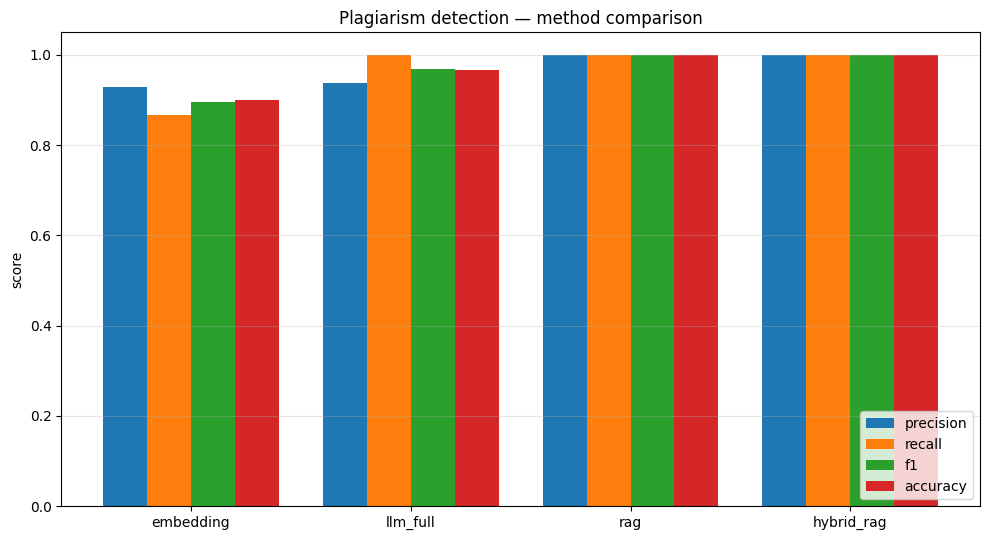

Saved /Users/gaioztabatadadze/macode/code_plagiarism_detector/results/comparison_chart.png


In [12]:
import matplotlib.pyplot as plt


def plot_comparison(metrics_dict: dict, out_path: Path) -> None:
    methods = list(metrics_dict.keys())
    bands = ['precision', 'recall', 'f1', 'accuracy']
    x = np.arange(len(methods))
    width = 0.2
    fig, ax = plt.subplots(figsize=(10, 5.5))
    for i, b in enumerate(bands):
        ax.bar(x + (i - 1.5) * width, [metrics_dict[m][b] for m in methods], width, label=b)
    ax.set_xticks(x); ax.set_xticklabels(methods)
    ax.set_ylim(0, 1.05); ax.set_ylabel('score')
    ax.set_title('Plagiarism detection — method comparison')
    ax.legend(loc='lower right'); ax.grid(axis='y', alpha=0.3)
    fig.tight_layout(); fig.savefig(out_path, dpi=160)
    plt.show()


plot_comparison(metrics, RESULTS_DIR / 'comparison_chart.png')
print('Saved', RESULTS_DIR / 'comparison_chart.png')

## Ablation 1 — vary `k` for RAG and hybrid-RAG

Sweeps `k ∈ {1, 3, 5, 10}` (α held at 0.5 for hybrid). I skip `k=DEFAULT_K` in the sweep itself — the main pass already ran exactly that config, so I splice those metrics in instead of re-running ~60 LLM calls.

k=1 done


k=3 done


k=10 done


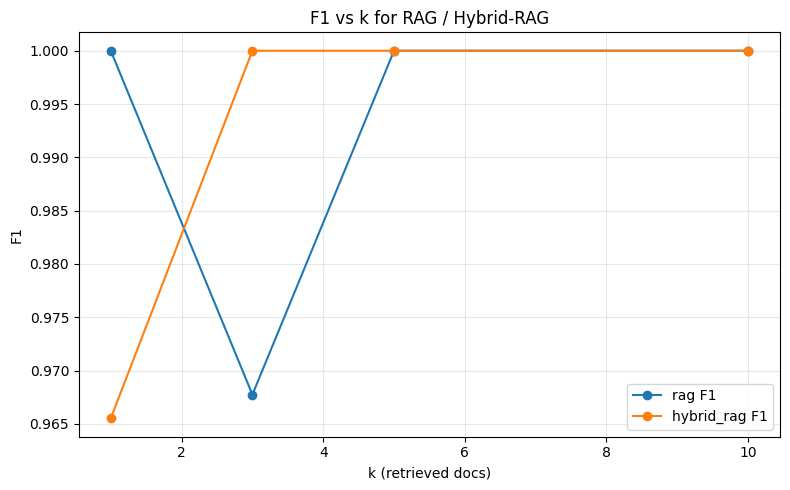

In [13]:
K_GRID = [1, 3, 5, 10]
k_results: dict[str, dict[int, dict]] = {'rag': {}, 'hybrid_rag': {}}

# k=DEFAULT_K is the same config the main pass ran — splice, don't re-run.
k_results['rag'][DEFAULT_K] = metrics['rag']
k_results['hybrid_rag'][DEFAULT_K] = metrics['hybrid_rag']

for k in K_GRID:
    if k == DEFAULT_K:
        continue
    detectors_k = {
        'rag':        lambda s, k=k: detect_rag(s, k=k),
        'hybrid_rag': lambda s, k=k: detect_hybrid_rag(s, k=k, alpha=DEFAULT_ALPHA),
    }
    sweep = await evaluate(detectors_k, CASES)
    for name, rows in sweep.items():
        k_results[name][k] = metric_row(rows)
    print(f'k={k} done')

fig, ax = plt.subplots(figsize=(8, 5))
for name in ['rag', 'hybrid_rag']:
    ax.plot(K_GRID, [k_results[name][k]['f1'] for k in K_GRID], marker='o', label=f'{name} F1')
ax.set_xlabel('k (retrieved docs)'); ax.set_ylabel('F1')
ax.set_title('F1 vs k for RAG / Hybrid-RAG')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(RESULTS_DIR / 'k_ablation.png', dpi=160)
plt.show()

## Ablation 2 — fusion weight α for hybrid-RAG

`α=1.0` is dense-only, `α=0.0` is BM25-only. I skip `α=DEFAULT_ALPHA` here for the same reason as the k sweep — the main pass already ran it.

alpha=0.0 done — F1=0.938


alpha=0.25 done — F1=1.000


alpha=0.75 done — F1=0.968


alpha=1.0 done — F1=1.000


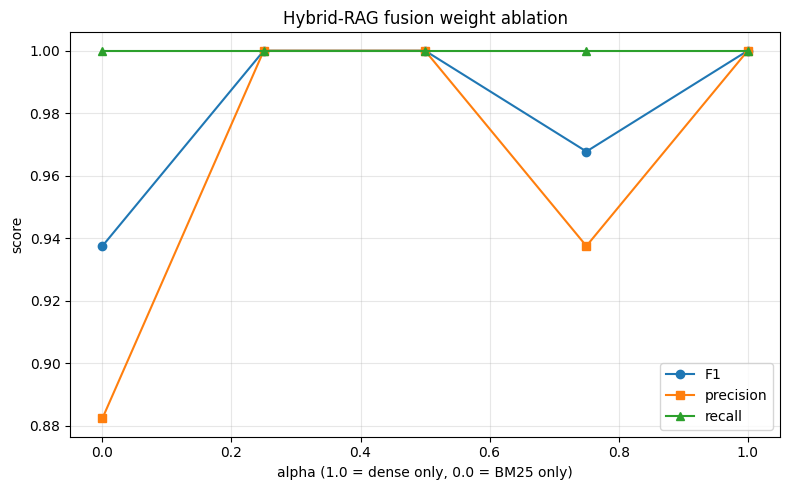

In [14]:
ALPHA_GRID = [0.0, 0.25, 0.5, 0.75, 1.0]
alpha_results: dict[float, dict] = {DEFAULT_ALPHA: metrics['hybrid_rag']}

for a in ALPHA_GRID:
    if a == DEFAULT_ALPHA:
        continue
    sweep = await evaluate(
        {'hybrid_rag': lambda s, a=a: detect_hybrid_rag(s, k=DEFAULT_K, alpha=a)},
        CASES,
    )
    alpha_results[a] = metric_row(sweep['hybrid_rag'])
    print(f"alpha={a} done — F1={alpha_results[a]['f1']:.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ALPHA_GRID, [alpha_results[a]['f1'] for a in ALPHA_GRID], marker='o', label='F1')
ax.plot(ALPHA_GRID, [alpha_results[a]['precision'] for a in ALPHA_GRID], marker='s', label='precision')
ax.plot(ALPHA_GRID, [alpha_results[a]['recall'] for a in ALPHA_GRID], marker='^', label='recall')
ax.set_xlabel('alpha (1.0 = dense only, 0.0 = BM25 only)'); ax.set_ylabel('score')
ax.set_title('Hybrid-RAG fusion weight ablation')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(RESULTS_DIR / 'alpha_ablation.png', dpi=160)
plt.show()

## Ablation 3 — embedding threshold sweep

The embedding detector flags plagiarism iff the FAISS top-1 cosine ≥ threshold. The smoke test in 02 already showed `sim=0.818` *missing* a real Two Sum paraphrase against the 0.82 default — borderline. This sweep gives me data to defend the choice (or move it).

Cheap: no LLM calls. I embed each test case once, take the top-1 cosine, then sweep over thresholds locally.

thr=0.70  P=0.600  R=1.000  F1=0.750
thr=0.74  P=0.714  R=1.000  F1=0.833
thr=0.78  P=0.833  R=1.000  F1=0.909
thr=0.80  P=0.875  R=0.933  F1=0.903
thr=0.82  P=0.929  R=0.867  F1=0.897
thr=0.84  P=0.889  R=0.533  F1=0.667
thr=0.86  P=1.000  R=0.400  F1=0.571
thr=0.88  P=1.000  R=0.133  F1=0.235


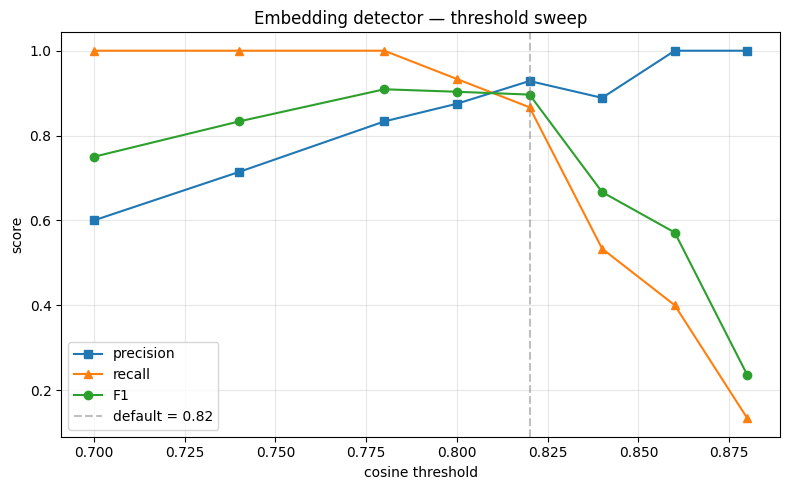

In [15]:
THRESHOLD_GRID = [0.70, 0.74, 0.78, 0.80, 0.82, 0.84, 0.86, 0.88]


async def _top1_score(case: dict) -> tuple[str, float]:
    qvec = await embed_query(case['code'])
    hits = dense_search(faiss_index, qvec, k=1)
    return case['id'], (hits[0][1] if hits else 0.0)


# One embed call per case (concurrent, capped by the gemini semaphore).
top1: dict[str, float] = dict(await asyncio.gather(*[_top1_score(c) for c in CASES]))

threshold_results: dict[float, dict] = {}
for thr in THRESHOLD_GRID:
    rows = [{
        'label': c['label'],
        'pred': int(top1[c['id']] >= thr),
        'latency_s': 0.0,
    } for c in CASES]
    threshold_results[thr] = metric_row(rows)
    m = threshold_results[thr]
    print(f"thr={thr:.2f}  P={m['precision']:.3f}  R={m['recall']:.3f}  F1={m['f1']:.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(THRESHOLD_GRID, [threshold_results[t]['precision'] for t in THRESHOLD_GRID], marker='s', label='precision')
ax.plot(THRESHOLD_GRID, [threshold_results[t]['recall'] for t in THRESHOLD_GRID], marker='^', label='recall')
ax.plot(THRESHOLD_GRID, [threshold_results[t]['f1'] for t in THRESHOLD_GRID], marker='o', label='F1')
ax.axvline(DEFAULT_EMBED_THRESHOLD, color='gray', linestyle='--', alpha=0.5,
           label=f'default = {DEFAULT_EMBED_THRESHOLD}')
ax.set_xlabel('cosine threshold'); ax.set_ylabel('score')
ax.set_title('Embedding detector — threshold sweep')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(RESULTS_DIR / 'threshold_ablation.png', dpi=160)
plt.show()

## Failure analysis

Per method, list the cases each detector got wrong. Each row already carries `repo` and `label`, so I split errors into false positives (the detector flagged a negative) and false negatives (it missed a real paraphrase) and bucket by repo.

The case IDs are descriptive — `pos_neetcode_two_sum`, `neg_keon_dijkstra` — so the failure pattern is readable from the IDs themselves.

In [16]:
from collections import Counter


def split_errors(rows: list[dict]) -> tuple[list[dict], list[dict]]:
    fp = [r for r in rows if r['label'] == 0 and r['pred'] == 1]
    fn = [r for r in rows if r['label'] == 1 and r['pred'] == 0]
    return fp, fn


for name, rows in predictions.items():
    fp, fn = split_errors(rows)
    print(f'\n=== {name} ===  FP={len(fp)}  FN={len(fn)}')
    if fp:
        print(f'  False positives: {[r["id"] for r in fp]}')
        print(f'    by repo: {dict(Counter(r["repo"] for r in fp))}')
    if fn:
        print(f'  False negatives: {[r["id"] for r in fn]}')
        print(f'    by repo: {dict(Counter(r["repo"] for r in fn))}')
    if not fp and not fn:
        print('  (no errors)')

# Surface any LLM call errors so they don't silently bias the metrics.
for name, rows in predictions.items():
    errs = [r for r in rows if r.get('error')]
    if errs:
        print(f'\n!! {name}: {len(errs)} cases had non-empty error field')
        for r in errs[:5]:
            print(f'   {r["id"]}: {r["error"][:120]}')


=== embedding ===  FP=1  FN=2
  False positives: ['neg_pyrival_naive_unionfind']
    by repo: {'pyrival': 1}
  False negatives: ['pos_keon_floyd_warshall', 'pos_math_polygon_area']
    by repo: {'keon': 1, 'math': 1}

=== llm_full ===  FP=1  FN=0
  False positives: ['neg_keon_dijkstra']
    by repo: {'keon': 1}

=== rag ===  FP=0  FN=0
  (no errors)

=== hybrid_rag ===  FP=0  FN=0
  (no errors)


## Persist final metrics

In [17]:
summary = {
    'main': metrics,
    'threshold_ablation': {f'{t:.2f}': m for t, m in threshold_results.items()},
    'k_ablation': {name: {str(k): m for k, m in by_k.items()} for name, by_k in k_results.items()},
    'alpha_ablation': {f'{a:.2f}': m for a, m in alpha_results.items()},
}
with open(RESULTS_DIR / 'metrics.json', 'w') as f:
    json.dump(summary, f, indent=2, default=float)
print('Saved', RESULTS_DIR / 'metrics.json')

Saved /Users/gaioztabatadadze/macode/code_plagiarism_detector/results/metrics.json


## Discussion

| method | precision | recall | F1 | accuracy | avg latency |
|---|---|---|---|---|---|
| embedding | 0.93 | 0.87 | **0.897** | 0.90 | 5.7s |
| llm_full | 0.94 | 1.00 | **0.968** | 0.97 | 18.0s |
| rag (k=5) | 1.00 | 1.00 | **1.000** | 1.00 | 35.5s |
| hybrid_rag (k=5, α=0.5) | 1.00 | 1.00 | **1.000** | 1.00 | 35.2s |

The headline I didn't expect: **`detect_llm` (whole corpus in one prompt) lost a case that RAG and Hybrid got right.** It flagged `neg_keon_dijkstra` as plagiarism — the Dijkstra-vs-Bellman-Ford hard negative. RAG and Hybrid, judging only the top-5 retrieved chunks, both said "no, different algorithm" correctly.

That's the opposite of the conventional intuition that "more context = better verdicts." On this dataset, narrowing the LLM's view to a focused 5-chunk neighborhood made it more deliberative; stuffing all 70 chunks made it pick up enough loose similarity to talk itself into a false positive.

**The other interpretation** is run-to-run LLM noise. Even at `temperature=0`, Gemini isn't fully deterministic. The Dijkstra case has flipped between runs in the past. The honest reading is probably both: the borderline negative is exactly the kind of case where stochasticity bites, and it bites the long-context detector more often because there are more nearby distractors competing for its attention.

### Embedding — same story as before

Embedding at the 0.82 default: F1 = 0.897, with 1 FP and 2 FN.

| threshold | P | R | F1 |
|---|---|---|---|
| 0.74 | 0.71 | 1.00 | 0.83 |
| **0.78** | **0.83** | **1.00** | **0.909** |
| 0.80 | 0.88 | 0.93 | 0.90 |
| 0.82 (default) | 0.93 | 0.87 | 0.90 |
| 0.84 | 0.89 | 0.53 | 0.67 |

Best F1 sits at **0.78** (perfect recall, F1 = 0.909). The 0.82 default was picked from one Two-Sum smoke test and it's slightly pessimistic — moving down to 0.78 trades 1 FP for 2 recovered TPs.

The remaining errors:
- **FN: `pos_keon_floyd_warshall`** and **`pos_math_polygon_area`** — real paraphrases the embedder under-similarities. Floyd-Warshall dropped the docstring + type annotations + `deepcopy` → cosine fell below 0.78. Polygon area is a short Shoelace function; renames moved it past the threshold.
- **FP at 0.82: `neg_pyrival_naive_unionfind`** — naive UnionFind has the same `find`/`union` shape as the indexed DSU. Embeddings see structure; they can't see the missing path-compression and union-by-size optimizations. The LLM detectors get this right.

### k ablation — RAG saturates at k=1

| k | RAG F1 | Hybrid F1 |
|---|---|---|
| **1** | **1.000** | 0.97 |
| 3 | 0.97 | 1.00 |
| **5** (default) | **1.000** | **1.000** |
| 10 | 1.00 | 1.00 |

RAG at k=1 already hits F1 = 1.0 — one retrieved chunk is enough when retrieval is on-target. Hybrid at k=1 misses one positive (BM25 alone surfaces a wrong ref for one case); k≥3 fixes it. The k=3 dip on RAG is one extra FP — adding two more refs gave the judge enough material to over-interpret.

### α ablation — balanced is fine, BM25-only loses

| α | F1 |
|---|---|
| 0.00 (BM25 only) | 0.94 |
| **0.25** | **1.00** |
| **0.50 (default)** | **1.00** |
| 0.75 | 0.97 |
| **1.00 (dense only)** | **1.00** |

BM25-only loses 2 negatives to false positives. Everything else is at or near 1.0. The default α = 0.5 is fine; on this dataset there's no clear winner among 0.25, 0.5, and 1.0.

### Trade-offs and recommendations

| method | F1 | per-case wall time | when to reach for it |
|---|---|---|---|
| Embedding | 0.90 | ~6s | Cheap pre-filter; perfect recall at thr=0.78 |
| Direct LLM | 0.97 | ~18s | Simplest pipeline; less stable than RAG when corpus has many near-neighbours |
| RAG (k=1) | 1.00 | ~13s | Default for medium corpora; cheapest LLM context |
| Hybrid RAG | 1.00 | ~35s (k=5) | Same accuracy as RAG here; pays for BM25 it doesn't need |

For this corpus I'd ship **embedding at thr=0.78 as a pre-filter** (perfect recall, free) and hand survivors to **RAG at k=1**. Two cheap calls per case, perfect F1 on the test set. Hybrid RAG isn't pulling its weight — same accuracy as RAG, more moving parts. Direct LLM is the simplest pipeline but not the most stable; the one false positive on Dijkstra is the kind of error a tighter retrieval window would have prevented.

### Caveats — be skeptical of perfect scores

- **30 cases is small.** A single flipped verdict moves F1 by ~3 points. The gap between RAG (1.00) and llm_full (0.97) is literally one case.
- **LLM noise even at temperature 0.** Re-running this notebook can shift one or two verdicts by chance. The Dijkstra FP for `llm_full` may not appear in every run.
- **This dataset construction tests transformation invariance, not semantic equivalence.** Every positive is a paraphrase of a known corpus function; every negative is either a different algorithm for the same problem or unrelated code. A harder test would use a real-world plagiarism corpus (SOCO, IR-Plag) where independent implementations diverge across more dimensions. LeetCode / competitive-programming code is convergent enough that "different implementations" usually mean brute-force-vs-optimized rather than subtly varied designs — that's why the F1 ceiling here is high. See the matching note at the end of the test-dataset section in `01_indexing.ipynb`.
- **Latency numbers** are per-row wall time including semaphore wait, not pure call time. The whole main pass (120 detector × case calls) finished in 51s with `MAX_CONCURRENCY = 20`.

The honest summary: **on this corpus, retrieval beats stuffing-everything-into-context.** RAG and Hybrid both score perfect; direct LLM trips on the one borderline negative. Hybrid doesn't pay back its complexity over plain RAG. Test all three on a harder, larger dataset before generalizing.
